In [3]:
from pathlib import Path
import pandas as pd

COUNT_FILE = Path(
    "../results/featurecounts_chr17/RNAseq_chr17_gene_counts.txt"
)

counts = pd.read_csv(
    COUNT_FILE,
    sep="\t",
    comment="#"
)

counts = counts.rename(
    columns={counts.columns[-1]: "Count"}
)

counts.head()

,Geneid,Chr,Start,End,Strand,Length,Count
0,ENSG00000280279,chr17;chr17;chr17;chr17;chr17,64099;65830;71366;75814;76723,65736;65887;71556;75878;76866,-;-;-;-;-,2096,24
1,ENSG00000280136,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr17,88641;97269;98893;101109;102058;105560;106755;...,88705;97797;98951;101174;102273;105691;106864;...,-;-;-;-;-;-;-;-,1373,15
2,ENSG00000277613,chr17,90796,90899,-,104,0
3,ENSG00000268320,chr17;chr17;chr17,137526;138203;138910,137645;138402;139067,+;+;+,478,0
4,ENSG00000272636,chr17;chr17;chr17;chr17;chr17;chr17;chr17;chr1...,142789;148173;149111;156019;156220;161415;1614...,147577;148269;149192;156377;156377;161541;1615...,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,6462,0


In [4]:
print("GTF에 등록된 전체 유전자:", len(counts))
print("Count가 1 이상인 유전자:", (counts["Count"] > 0).sum())
print("전체 assigned fragment:", counts["Count"].sum())

GTF에 등록된 전체 유전자: 3024
Count가 1 이상인 유전자: 1515
전체 assigned fragment: 1148261


## featureCounts 결과 탐색

단일 샘플이므로 차등발현 분석 대신, 검출된 유전자 비율과 count 분포 및 raw count 상위 유전자를 확인합니다.

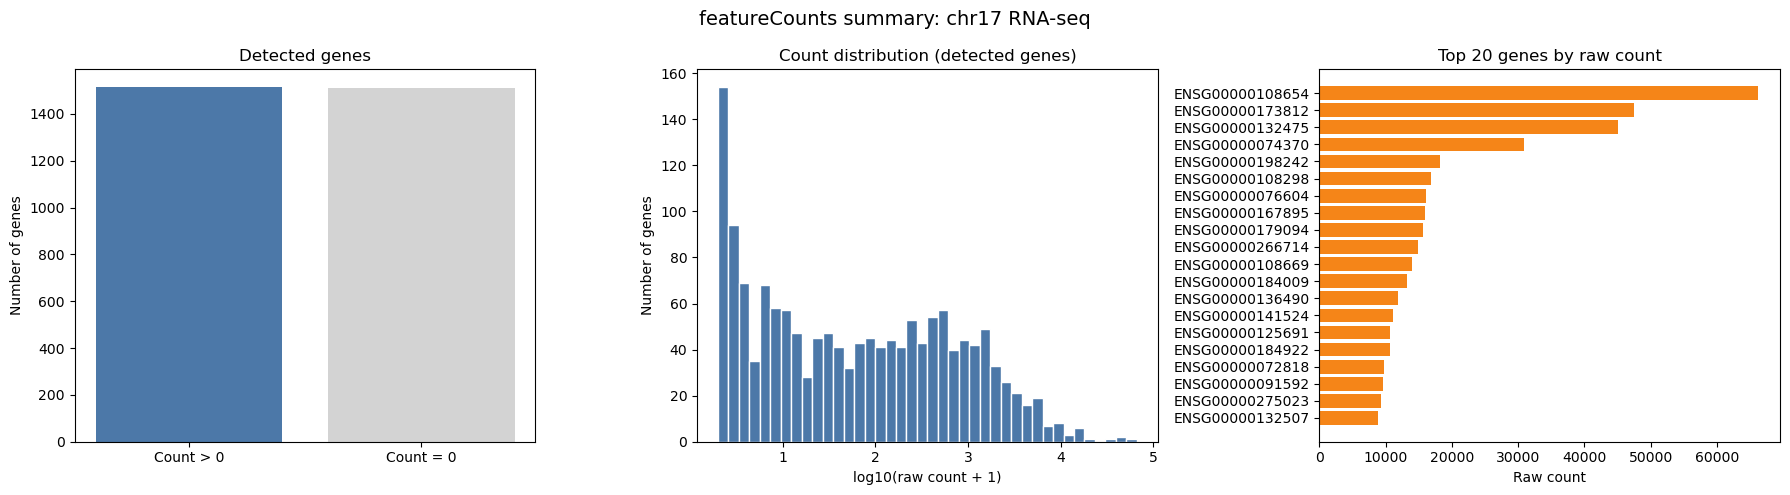

In [5]:
import numpy as np
import matplotlib.pyplot as plt

expressed = (counts["Count"] > 0).sum()
not_expressed = (counts["Count"] == 0).sum()
top20 = counts.nlargest(20, "Count").sort_values("Count")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(
    ["Count > 0", "Count = 0"],
    [expressed, not_expressed],
    color=["#4C78A8", "#D3D3D3"]
)
axes[0].set_title("Detected genes")
axes[0].set_ylabel("Number of genes")

axes[1].hist(
    np.log10(counts.loc[counts["Count"] > 0, "Count"] + 1),
    bins=40,
    color="#4C78A8",
    edgecolor="white"
)
axes[1].set_title("Count distribution (detected genes)")
axes[1].set_xlabel("log10(raw count + 1)")
axes[1].set_ylabel("Number of genes")

axes[2].barh(top20["Geneid"], top20["Count"], color="#F58518")
axes[2].set_title("Top 20 genes by raw count")
axes[2].set_xlabel("Raw count")

fig.suptitle("featureCounts summary: chr17 RNA-seq", fontsize=14)
fig.tight_layout()
plt.show()


> **해석 주의:** 위 상위 유전자 그래프는 raw count 기준입니다. 유전자 길이와 sequencing depth의 영향을 받으므로, 서로 다른 유전자의 실제 발현량을 엄밀히 비교하려면 다음 단계에서 TPM 등의 정규화가 필요합니다.